# Analysis Flash Attention

In [53]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

## Setup

In [56]:
# Load all dataset
df_all = pd.read_csv("../results/metrics/all_results.csv")

# Filter just FA
df_fa = df_all[df_all['label'].str.contains("standard_len|flash_attn_len")].copy()

# Split standard vs flash_attn
df_standard = df_fa[df_fa['label'].str.contains('standard_len')]
df_flash = df_fa[df_fa['label'].str.contains('flash_attn_len')]

all_results = []
for root, dirs, fs in os.walk("../results/"):
    for f in fs:
        if f.startswith(('standard', 'flash')) and "trace" not in f:
            json_path = os.path.join(root, f)
            with open(json_path) as f:
                all_results.append(json.load(f))

data = pd.DataFrame(all_results)
df_standard['prompt_length'] = data[data['label'].str.contains('standard_len')]['prompt_length'].tolist()
df_flash['prompt_length'] = data[data['label'].str.contains('flash_attn_len')]['prompt_length'].tolist()

# Extract prompt length sebagai integer untuk plotting
df_standard["prompt_len"] = df_standard["prompt_length"].astype(int)
df_flash["prompt_len"]    = df_flash["prompt_length"].astype(int)

# Sort by prompt length
df_standard = df_standard.sort_values("prompt_len")
df_flash    = df_flash.sort_values("prompt_len")

# Load JSON untuk itl_per_position di len(1024)
with open("../results/metrics/standard_len(1024).json") as f:
    std_1024 = json.load(f)

with open("../results/metrics/flash_attn_len(1024).json") as f:
    fa_1024 = json.load(f)

std_itl  = np.array(std_1024["itl_per_position"])
fa_itl   = np.array(fa_1024["itl_per_position"])

print("Standard lengths:", df_standard["prompt_len"].tolist())
print("Flash lengths:   ", df_flash["prompt_len"].tolist())
print(f"\nStd  ITL positions: {len(std_itl)}, max: {std_itl.max():.1f}ms at pos {std_itl.argmax()}")
print(f"FA   ITL positions: {len(fa_itl)},  max: {fa_itl.max():.1f}ms at pos {fa_itl.argmax()}")

Standard lengths: [133, 265, 518, 1024]
Flash lengths:    [133, 265, 518, 1024]

Std  ITL positions: 300, max: 258.0ms at pos 0
FA   ITL positions: 300,  max: 356.8ms at pos 0


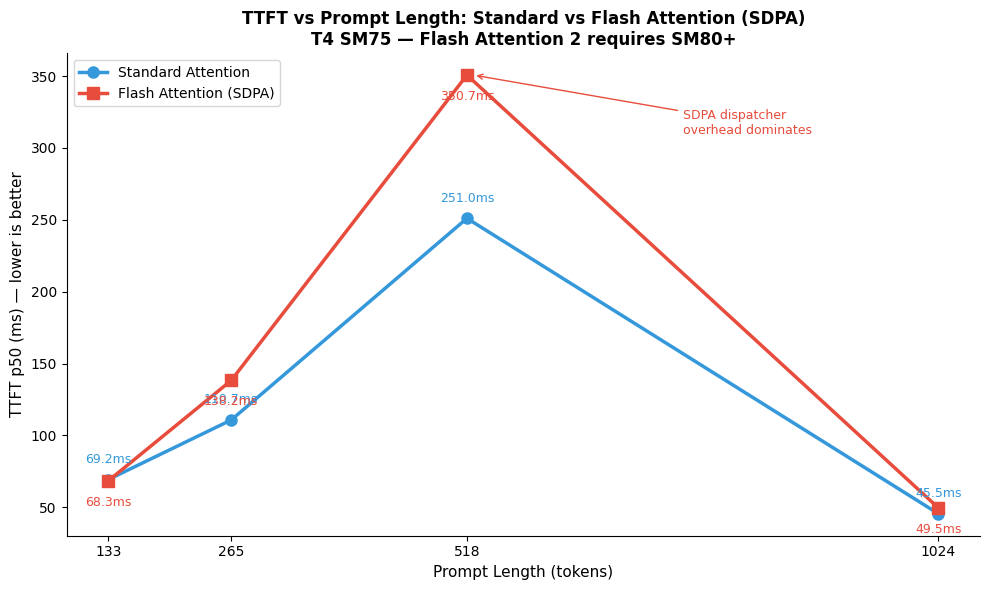

len= 133: standard=69.2ms, sdpa=68.3ms, SDPA overhead=-1.3%
len= 265: standard=110.7ms, sdpa=138.2ms, SDPA overhead=+24.9%
len= 518: standard=251.0ms, sdpa=350.7ms, SDPA overhead=+39.7%
len=1024: standard=45.5ms, sdpa=49.5ms, SDPA overhead=+8.8%


In [59]:
fig, ax = plt.subplots(figsize=(10, 6))

lengths   = df_standard["prompt_len"].tolist()
std_ttft  = df_standard["ttft_p50_ms"].tolist()
fa_ttft   = df_flash["ttft_p50_ms"].tolist()

ax.plot(lengths, std_ttft,
        color="#3498db", marker="o", linewidth=2.5,
        markersize=8, label="Standard Attention")

ax.plot(lengths, fa_ttft,
        color="#e74c3c", marker="s", linewidth=2.5,
        markersize=8, label="Flash Attention (SDPA)")

# Annotate values
for x, y in zip(lengths, std_ttft):
    ax.annotate(f"{y:.1f}ms",
                (x, y), textcoords="offset points",
                xytext=(0, 12), ha="center",
                fontsize=9, color="#3498db")

for x, y in zip(lengths, fa_ttft):
    ax.annotate(f"{y:.1f}ms",
                (x, y), textcoords="offset points",
                xytext=(0, -18), ha="center",
                fontsize=9, color="#e74c3c")

# Annotate FA overhead at 1024
ax.annotate("SDPA dispatcher\noverhead dominates",
            xy=(525, 350.7),
            xytext=(750, 310),
            fontsize=9, color="#e74c3c",
            arrowprops=dict(arrowstyle="->", color="#e74c3c"))

ax.set_xlabel("Prompt Length (tokens)", fontsize=11)
ax.set_ylabel("TTFT p50 (ms) — lower is better", fontsize=11)
ax.set_title("TTFT vs Prompt Length: Standard vs Flash Attention (SDPA)\n"
             "T4 SM75 — Flash Attention 2 requires SM80+",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xticks(lengths)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
Path("../results/figures/flash_attention").mkdir(parents=True, exist_ok=True)
plt.savefig("../results/figures/flash_attention/ttft_vs_sequence_length.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print ratio
for l, s, f in zip(lengths, std_ttft, fa_ttft):
    overhead_pct = ((f - s) / s) * 100
    print(f"len={l:4d}: standard={s:.1f}ms, sdpa={f:.1f}ms, "
          f"SDPA overhead={overhead_pct:+.1f}%")

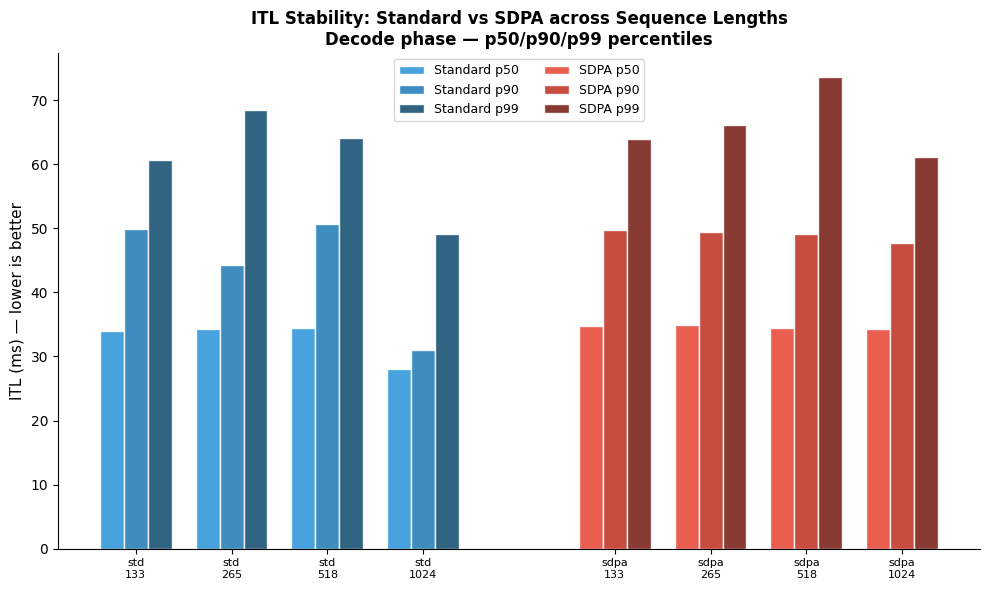

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))

x      = np.arange(len(lengths))
width  = 0.25

std_p50 = df_standard["itl_p50_ms"].tolist()
std_p90 = df_standard["itl_p90_ms"].tolist()
std_p99 = df_standard["itl_p99_ms"].tolist()

fa_p50  = df_flash["itl_p50_ms"].tolist()
fa_p90  = df_flash["itl_p90_ms"].tolist()
fa_p99  = df_flash["itl_p99_ms"].tolist()

# Standard — grouped bars
bars1 = ax.bar(x - width, std_p50, width, label="Standard p50",
               color="#3498db", alpha=0.9, edgecolor="white")
bars2 = ax.bar(x,          std_p90, width, label="Standard p90",
               color="#2980b9", alpha=0.9, edgecolor="white")
bars3 = ax.bar(x + width,  std_p99, width, label="Standard p99",
               color="#1a5276", alpha=0.9, edgecolor="white")

# Flash 
offset = len(lengths) + 1
x2     = np.arange(offset, offset + len(lengths))

bars4 = ax.bar(x2 - width, fa_p50, width, label="SDPA p50",
               color="#e74c3c", alpha=0.9, edgecolor="white")
bars5 = ax.bar(x2,          fa_p90, width, label="SDPA p90",
               color="#c0392b", alpha=0.9, edgecolor="white")
bars6 = ax.bar(x2 + width,  fa_p99, width, label="SDPA p99",
               color="#7b241c", alpha=0.9, edgecolor="white")

# X labels
all_x      = np.concatenate([x, x2])
all_labels = [f"std\n{l}" for l in lengths] + [f"sdpa\n{l}" for l in lengths]
ax.set_xticks(all_x)
ax.set_xticklabels(all_labels, fontsize=8)

ax.set_ylabel("ITL (ms) — lower is better", fontsize=11)
ax.set_title("ITL Stability: Standard vs SDPA across Sequence Lengths\n"
             "Decode phase — p50/p90/p99 percentiles",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, ncol=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/flash_attention/itl_stability_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

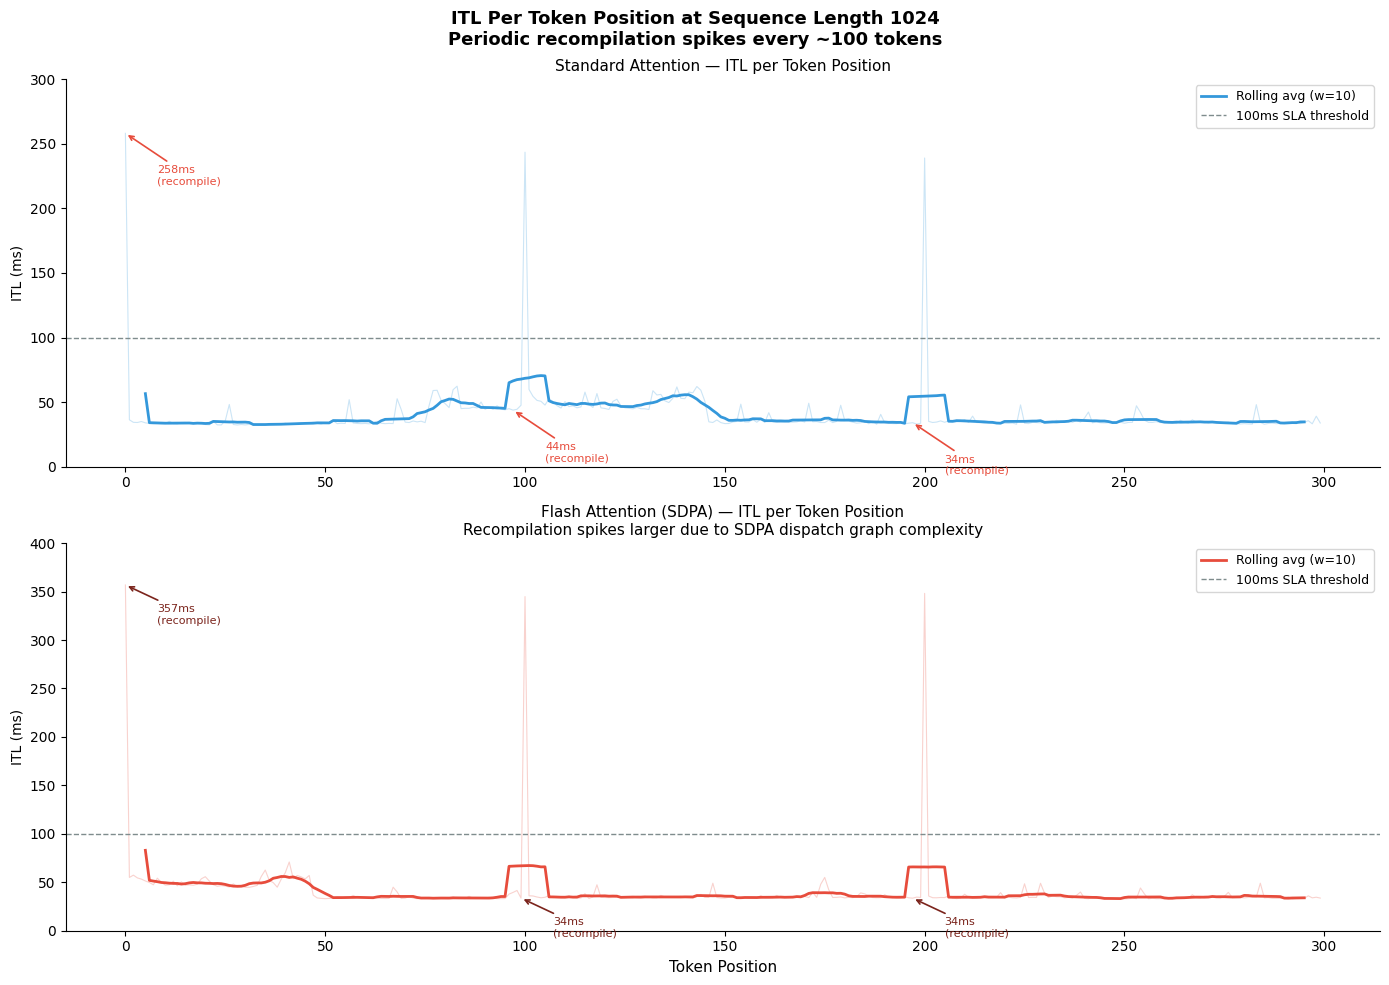

Recompilation spike comparison:
  Standard pos~97:  44ms
  SDPA     pos~99:  34ms
  SDPA spike is 0.8x larger

Tokens above 100ms SLA:
  Standard: 3 tokens
  SDPA:     3 tokens


In [63]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
fig.suptitle("ITL Per Token Position at Sequence Length 1024\n"
             "Periodic recompilation spikes every ~100 tokens",
             fontsize=13, fontweight="bold")

positions = np.arange(len(std_itl))
window    = 10

std_smooth = np.convolve(std_itl, np.ones(window)/window, mode='valid')
fa_smooth  = np.convolve(fa_itl,  np.ones(window)/window, mode='valid')

# Standard
axes[0].plot(positions, std_itl,
             color="#3498db", alpha=0.25, linewidth=0.8)
axes[0].plot(np.arange(len(std_smooth)) + window//2, std_smooth,
             color="#3498db", linewidth=2, label=f"Rolling avg (w={window})")

# Annotate recompilation spikes
for pos, val in [(0, std_itl[0]), (97, std_itl[97]), (197, std_itl[197])]:
    axes[0].annotate(f"{val:.0f}ms\n(recompile)",
                     xy=(pos, val),
                     xytext=(pos + 8, val - 40),
                     fontsize=8, color="#e74c3c",
                     arrowprops=dict(arrowstyle="->",
                                     color="#e74c3c", lw=1.2))

axes[0].axhline(y=100, color="#7f8c8d", linestyle="--",
                linewidth=1, label="100ms SLA threshold")
axes[0].set_title("Standard Attention — ITL per Token Position", fontsize=11)
axes[0].set_ylabel("ITL (ms)")
axes[0].set_ylim(0, 300)
axes[0].legend(fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Flash Attention (SDPA)
fa_positions = np.arange(len(fa_itl))
axes[1].plot(fa_positions, fa_itl,
             color="#e74c3c", alpha=0.25, linewidth=0.8)
axes[1].plot(np.arange(len(fa_smooth)) + window//2, fa_smooth,
             color="#e74c3c", linewidth=2, label=f"Rolling avg (w={window})")

for pos, val in [(0, fa_itl[0]), (99, fa_itl[99]), (197, fa_itl[197])]:
    axes[1].annotate(f"{val:.0f}ms\n(recompile)",
                     xy=(pos, val),
                     xytext=(pos + 8, val - 40),
                     fontsize=8, color="#7b241c",
                     arrowprops=dict(arrowstyle="->",
                                     color="#7b241c", lw=1.2))

axes[1].axhline(y=100, color="#7f8c8d", linestyle="--",
                linewidth=1, label="100ms SLA threshold")
axes[1].set_title("Flash Attention (SDPA) — ITL per Token Position\n"
                  "Recompilation spikes larger due to SDPA dispatch graph complexity",
                  fontsize=11)
axes[1].set_ylabel("ITL (ms)")
axes[1].set_xlabel("Token Position", fontsize=11)
axes[1].set_ylim(0, 400)
axes[1].legend(fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/flash_attention/itl_per_position_1024.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Stats
print("Recompilation spike comparison:")
print(f"  Standard pos~97:  {std_itl[97]:.0f}ms")
print(f"  SDPA     pos~99:  {fa_itl[99]:.0f}ms")
print(f"  SDPA spike is {fa_itl[99]/std_itl[97]:.1f}x larger")
print(f"\nTokens above 100ms SLA:")
print(f"  Standard: {(std_itl > 100).sum()} tokens")
print(f"  SDPA:     {(fa_itl > 100).sum()} tokens")

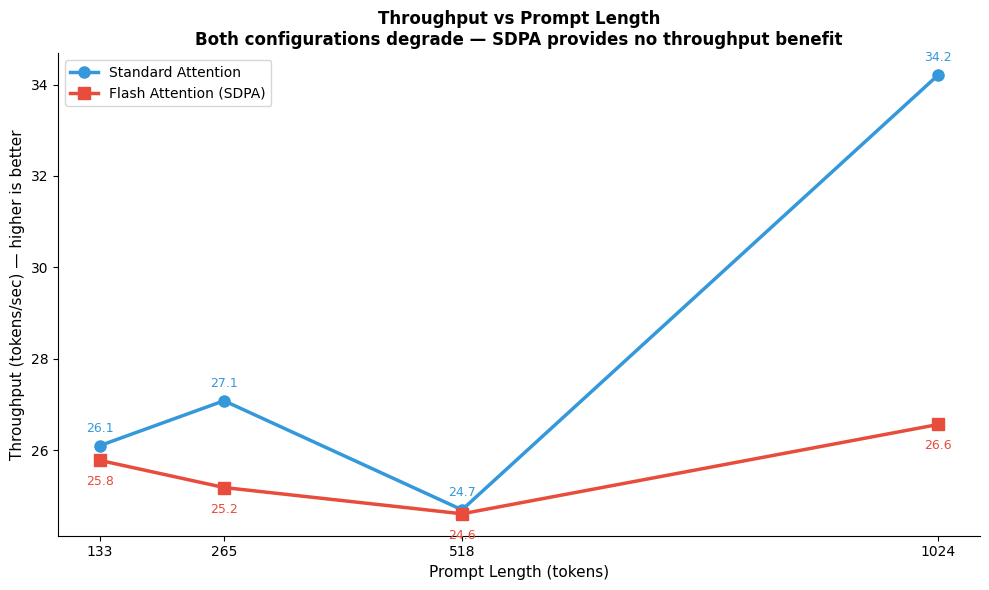

len= 133: standard=26.1 tps, sdpa=25.8 tps
len= 265: standard=27.1 tps, sdpa=25.2 tps
len= 518: standard=24.7 tps, sdpa=24.6 tps
len=1024: standard=34.2 tps, sdpa=26.6 tps


In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

std_tps = df_standard["throughput_tps"].tolist()
fa_tps  = df_flash["throughput_tps"].tolist()

ax.plot(lengths, std_tps,
        color="#3498db", marker="o", linewidth=2.5,
        markersize=8, label="Standard Attention")
ax.plot(lengths, fa_tps,
        color="#e74c3c", marker="s", linewidth=2.5,
        markersize=8, label="Flash Attention (SDPA)")

for x, y in zip(lengths, std_tps):
    ax.annotate(f"{y:.1f}",
                (x, y), textcoords="offset points",
                xytext=(0, 10), ha="center",
                fontsize=9, color="#3498db")

for x, y in zip(lengths, fa_tps):
    ax.annotate(f"{y:.1f}",
                (x, y), textcoords="offset points",
                xytext=(0, -18), ha="center",
                fontsize=9, color="#e74c3c")

ax.set_xlabel("Prompt Length (tokens)", fontsize=11)
ax.set_ylabel("Throughput (tokens/sec) — higher is better", fontsize=11)
ax.set_title("Throughput vs Prompt Length\n"
             "Both configurations degrade — SDPA provides no throughput benefit",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xticks(lengths)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/flash_attention/throughput_vs_sequence_length.png",
            dpi=150, bbox_inches="tight")
plt.show()

for l, s, f in zip(lengths, std_tps, fa_tps):
    print(f"len={l:4d}: standard={s:.1f} tps, sdpa={f:.1f} tps")